In [45]:
"""
Final Hybrid Model: ResNet-50 + CBAM + Vision Transformer
For Pneumothorax Detection with Enhanced Localization

Architecture:
- ResNet-50V2 backbone (frozen initially)
- CBAM attention for spatial/channel focus
- Vision Transformer for global context
- Binary classification with interpretability
"""

import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.10.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 5e-4

# Transformer config
NUM_TRANSFORMER_BLOCKS = 6
HEAD_SIZE = 64
NUM_HEADS = 8
FF_DIM = 256
TRANSFORMER_DROPOUT = 0.1
PROJECTED_DIM = 512

# CBAM config
CBAM_RATIO = 8
CBAM_KERNEL_SIZE = 7

# Regularization
DROPOUT_RATE = 0.1
MLP_UNITS = [512]

print(f"\nConfiguration:")
print(f"  Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Transformer Blocks: {NUM_TRANSFORMER_BLOCKS}")
print(f"  Attention Heads: {NUM_HEADS}")


Configuration:
  Image Size: 224x224
  Batch Size: 32
  Epochs: 60
  Learning Rate: 0.0005
  Transformer Blocks: 6
  Attention Heads: 8


In [47]:
# ============================================================================
# LOAD PRE-BALANCED MULTI-LABEL DATASET
# ============================================================================

import glob

BASE_DIR = "../dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images", "new_images")

# Disease labels (14 diseases + No Finding)
CLASS_NAMES = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax', 'No Finding'
]
NUM_CLASSES = len(CLASS_NAMES)

print(f"\nLoading pre-balanced multi-label dataset...")

# Load labels CSV
df = pd.read_csv(CSV_PATH)

# Create full image paths
df['image_path'] = df['Path'].apply(lambda x: os.path.join(IMAGE_DIR, x))

print(f"✓ Loaded {len(df):,} images with labels")
print(f"\nClass distribution:")
for class_name in CLASS_NAMES:
    count = int(df[class_name].sum())
    pct = (count / len(df)) * 100
    print(f"  {class_name:20s}: {count:6,} ({pct:5.2f}%)")


Loading pre-balanced multi-label dataset...
✓ Loaded 51,382 images with labels

Class distribution:
  Atelectasis         :  4,788 ( 9.32%)
  Cardiomegaly        :  4,629 ( 9.01%)
  Consolidation       :  4,481 ( 8.72%)
  Edema               :  4,554 ( 8.86%)
  Effusion            :  5,000 ( 9.73%)
  Emphysema           :  4,467 ( 8.69%)
  Fibrosis            :  5,039 ( 9.81%)
  Hernia              :  5,590 (10.88%)
  Infiltration        :  5,740 (11.17%)
  Mass                :  5,564 (10.83%)
  Nodule              :  5,634 (10.96%)
  Pleural_Thickening  :  4,831 ( 9.40%)
  Pneumonia           :  6,105 (11.88%)
  Pneumothorax        :  4,919 ( 9.57%)
  No Finding          :  5,000 ( 9.73%)


In [48]:
# ============================================================================
# TRAIN/VAL SPLIT (80/20)
# ============================================================================

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print(f"\nDataset split:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Val: {len(val_df):,} samples")


Dataset split:
  Train: 41,105 samples
  Val: 10,277 samples


In [49]:
# ============================================================================
# CBAM ATTENTION MODULE
# ============================================================================

class ChannelAttention(layers.Layer):
    """Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio
    
    def build(self, input_shape):
        channels = input_shape[-1]
        self.shared_dense_one = layers.Dense(
            channels // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True
        )
        self.shared_dense_two = layers.Dense(
            channels,
            kernel_initializer='he_normal',
            use_bias=True
        )
        super(ChannelAttention, self).build(input_shape)
    
    def call(self, inputs):
        avg_pool = layers.GlobalAveragePooling2D()(inputs)
        avg_pool = layers.Reshape((1, 1, inputs.shape[-1]))(avg_pool)
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)
        
        max_pool = layers.GlobalMaxPooling2D()(inputs)
        max_pool = layers.Reshape((1, 1, inputs.shape[-1]))(max_pool)
        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)
        
        channel_attention = layers.Add()([avg_pool, max_pool])
        channel_attention = layers.Activation('sigmoid')(channel_attention)
        
        return layers.Multiply()([inputs, channel_attention])
    
    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


class SpatialAttention(layers.Layer):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
    
    def build(self, input_shape):
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False
        )
        super(SpatialAttention, self).build(input_shape)
    
    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        spatial_attention = self.conv(concat)
        return layers.Multiply()([inputs, spatial_attention])
    
    def get_config(self):
        config = super().get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


class CBAM(layers.Layer):
    """Convolutional Block Attention Module"""
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.channel_attention = ChannelAttention(ratio=ratio)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)
    
    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'ratio': self.ratio,
            'kernel_size': self.kernel_size
        })
        return config

In [50]:
# ============================================================================
# VISION TRANSFORMER ENCODER
# ============================================================================

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Vision Transformer Encoder Block"""
    # Layer norm + Multi-head attention
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads, 
        key_dim=head_size, 
        dropout=dropout
    )(x, x)
    x = layers.Add()([attention_output, inputs])
    
    # Feed-forward network
    ff_x = layers.LayerNormalization(epsilon=1e-6)(x)
    ff_x = layers.Dense(ff_dim, activation="gelu")(ff_x)
    ff_x = layers.Dropout(dropout)(ff_x)
    ff_x = layers.Dense(inputs.shape[-1])(ff_x)
    
    return layers.Add()([x, ff_x])

In [51]:
# ============================================================================
# HYBRID MODEL: ResNet-50 + CBAM + ViT
# ============================================================================

def create_hybrid_model(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=NUM_CLASSES,  # Multi-label: 15 classes
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    transformer_dropout=TRANSFORMER_DROPOUT,
    mlp_units=MLP_UNITS,
    dropout_rate=DROPOUT_RATE,
    projected_dim=PROJECTED_DIM,
    cbam_ratio=CBAM_RATIO,
    cbam_kernel_size=CBAM_KERNEL_SIZE
):
    """
    Hybrid architecture combining:
    - ResNet-50V2 for feature extraction
    - CBAM for attention-based feature refinement
    - Vision Transformer for global context
    
    Multi-label classification with sigmoid activation
    """
    
    print("\nBuilding Hybrid Model...")
    
    # ResNet-50V2 backbone
    resnet_base = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    resnet_base.trainable = False  # Freeze initially
    
    inputs = layers.Input(shape=input_shape)
    
    # Stage 1: ResNet feature extraction
    x = resnet_base(inputs, training=False)
    print(f"  ResNet output shape: {x.shape}")
    
    # Stage 2: CBAM attention
    x = CBAM(ratio=cbam_ratio, kernel_size=cbam_kernel_size, name='cbam')(x)
    print(f"  CBAM applied (ratio={cbam_ratio}, kernel={cbam_kernel_size})")
    
    # Stage 3: Reshape for transformer
    _, h, w, c = x.shape
    patches = layers.Reshape((h * w, c))(x)
    print(f"  Reshaped to patches: {patches.shape}")
    
    # Project to transformer dimension
    x = layers.LayerNormalization(epsilon=1e-6)(patches)
    x = layers.Dense(projected_dim)(x)
    print(f"  Projected to {projected_dim} dims")
    
    # Stage 4: Transformer encoder blocks
    for i in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, transformer_dropout)
    print(f"  {num_transformer_blocks} Transformer blocks applied")
    
    # Stage 5: Global pooling
    x = layers.GlobalAveragePooling1D()(x)
    
    # Stage 6: MLP head
    for dim in mlp_units:
        x = layers.Dense(dim, activation="gelu")(x)
        x = layers.Dropout(dropout_rate)(x)
    
    # Output
    outputs = layers.Dense(
        num_classes, 
        activation="sigmoid",
        kernel_regularizer=tf.keras.regularizers.l2(0.01)
    )(x)
    
    model = keras.Model(inputs, outputs, name='Hybrid_ResNet_CBAM_ViT')
    
    print(f"\n✓ Model built successfully!")
    print(f"  Total params: {model.count_params():,}")
    
    return model, resnet_base


# Create model
model, base_model = create_hybrid_model()


Building Hybrid Model...
  ResNet output shape: (None, 7, 7, 2048)
  CBAM applied (ratio=8, kernel=7)
  Reshaped to patches: (None, 49, 2048)
  Projected to 512 dims
  6 Transformer blocks applied

✓ Model built successfully!
  Total params: 33,832,817


In [52]:
# ============================================================================
# TF.DATA PIPELINE
# ============================================================================

def create_tf_dataset(df, batch_size, shuffle=True, augment=True):
    """Create optimized tf.data pipeline for multi-label"""
    
    def load_and_preprocess(image_path, labels):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
        
        if augment:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_brightness(img, 0.1)
            img = tf.image.random_contrast(img, 0.9, 1.1)
        
        img = tf.keras.applications.resnet_v2.preprocess_input(img)
        return img, labels
    
    image_paths = df['image_path'].values
    labels = df[CLASS_NAMES].values.astype(np.float32)  # Multi-label
    
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=42)
    
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

print("\nCreating datasets...")
train_dataset = create_tf_dataset(train_df, BATCH_SIZE, shuffle=True, augment=True)
val_dataset = create_tf_dataset(val_df, BATCH_SIZE, shuffle=False, augment=False)

print(f"✓ Datasets created")
print(f"  Train batches: {len(train_dataset)}")
print(f"  Val batches: {len(val_dataset)}")


Creating datasets...
✓ Datasets created
  Train batches: 1285
  Val batches: 322


In [53]:
# ============================================================================
# COMPILATION
# ============================================================================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        'binary_accuracy',
        tf.keras.metrics.AUC(name='auc', multi_label=True),  # Multi-label AUC
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("\n✓ Model compiled")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Loss: binary_crossentropy")


✓ Model compiled
  Optimizer: Adam (lr=0.0005)
  Loss: binary_crossentropy


In [54]:
# ============================================================================
# CALLBACKS
# ============================================================================

os.makedirs('./output', exist_ok=True)

callbacks = [
    ModelCheckpoint(
        filepath='./output/hybrid_model_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_auc',
        patience=15,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

In [55]:
# ============================================================================
# TRAINING
# ============================================================================

print("\n" + "="*80)
print("TRAINING HYBRID MODEL: ResNet-50 + CBAM + ViT")
print("="*80)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

model.save('./output/hybrid_model_final.keras')
print("\n✓ Training complete! Model saved.")


TRAINING HYBRID MODEL: ResNet-50 + CBAM + ViT
Epoch 1/60
1285/1285 [==============================] - ETA: 0s - loss: 0.3318 - binary_accuracy: 0.9041 - auc: 0.7095 - precision: 0.6132 - recall: 0.0818
Epoch 1: val_auc improved from -inf to 0.76241, saving model to ./output\hybrid_model_best.keras
1285/1285 [==============================] - 255s 163ms/step - loss: 0.3318 - binary_accuracy: 0.9041 - auc: 0.7095 - precision: 0.6132 - recall: 0.0818 - val_loss: 0.2788 - val_binary_accuracy: 0.9060 - val_auc: 0.7624 - val_precision: 0.7484 - val_recall: 0.0838 - lr: 5.0000e-04
Epoch 2/60
1285/1285 [==============================] - ETA: 0s - loss: 0.2751 - binary_accuracy: 0.9079 - auc: 0.7504 - precision: 0.7118 - recall: 0.1166
Epoch 2: val_auc did not improve from 0.76241
1285/1285 [==============================] - 222s 173ms/step - loss: 0.2751 - binary_accuracy: 0.9079 - auc: 0.7504 - precision: 0.7118 - recall: 0.1166 - val_loss: 0.2794 - val_binary_accuracy: 0.9074 - val_auc: 0.7

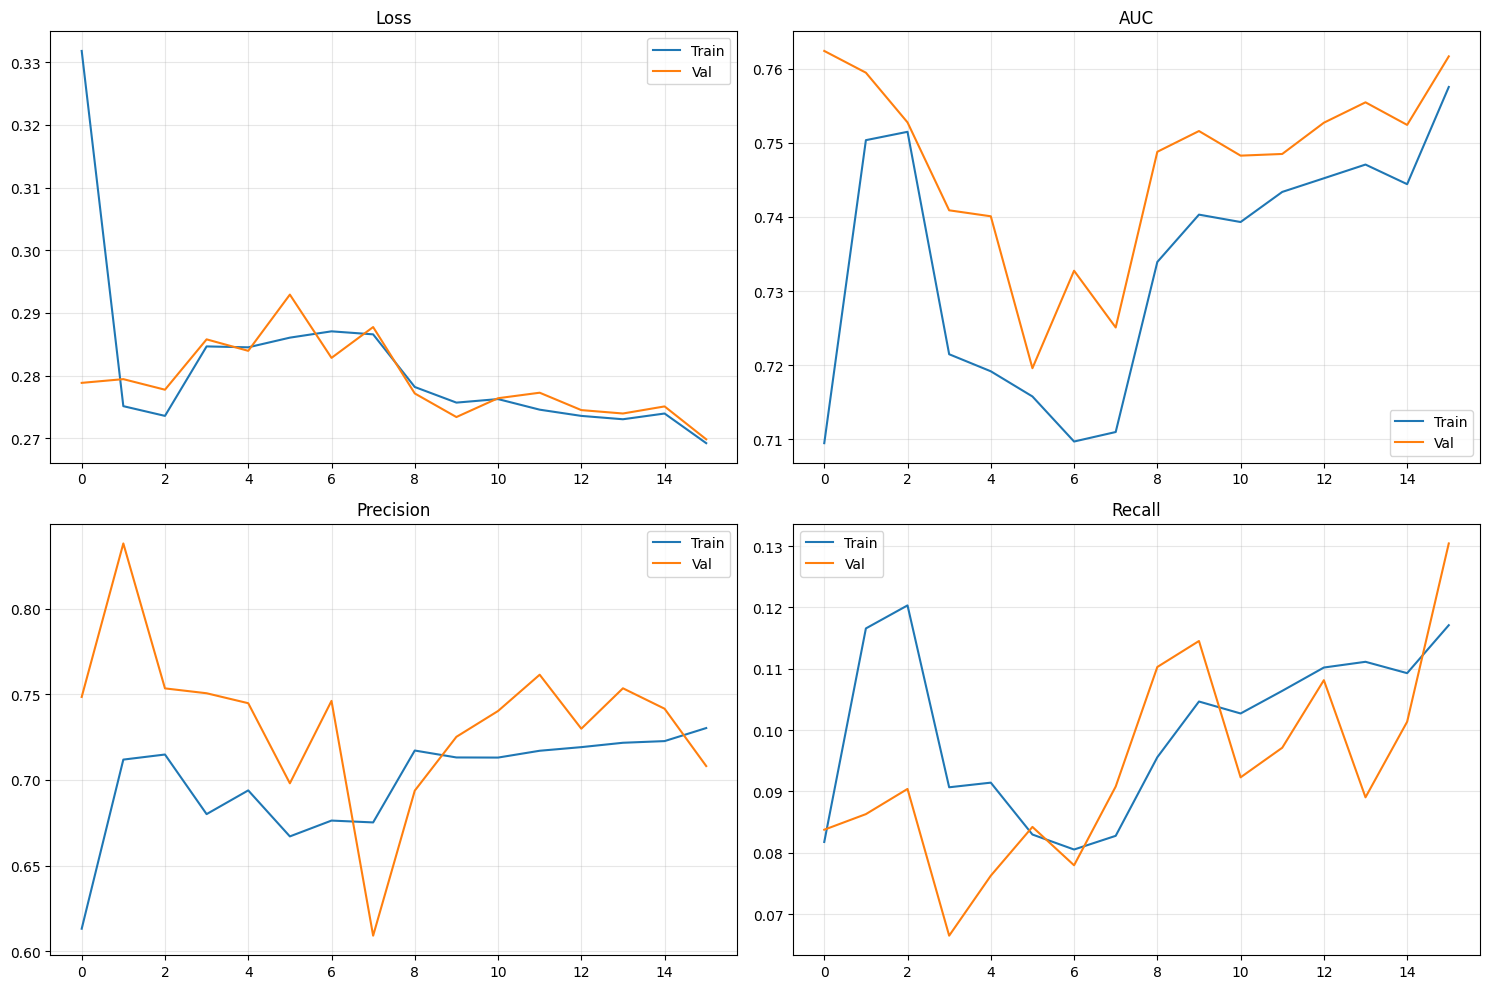

In [56]:
# ============================================================================
# TRAINING HISTORY VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train')
axes[0, 0].plot(history.history['val_loss'], label='Val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# AUC
axes[0, 1].plot(history.history['auc'], label='Train')
axes[0, 1].plot(history.history['val_auc'], label='Val')
axes[0, 1].set_title('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history.history['precision'], label='Train')
axes[1, 0].plot(history.history['val_precision'], label='Val')
axes[1, 0].set_title('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history.history['recall'], label='Train')
axes[1, 1].plot(history.history['val_recall'], label='Val')
axes[1, 1].set_title('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./output/hybrid_training_history.png', dpi=300)
plt.show()

In [57]:
# ============================================================================
# COMPREHENSIVE EVALUATION
# ============================================================================

from sklearn.metrics import f1_score, classification_report, roc_auc_score

print("\n" + "="*80)
print("COMPREHENSIVE EVALUATION ON VALIDATION SET")
print("="*80)

# Generate predictions
print("\nGenerating predictions...")
predictions = model.predict(val_dataset, verbose=1)
y_true = val_df[CLASS_NAMES].values
y_pred_binary = (predictions > 0.5).astype(int)

# Overall metrics
print("\n" + "="*80)
print("OVERALL METRICS")
print("="*80)

# Micro metrics (aggregate all classes)
micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)

# Per-class AUC
per_class_aucs = []
for i, class_name in enumerate(CLASS_NAMES):
    try:
        if len(np.unique(y_true[:, i])) > 1:
            auc_score = roc_auc_score(y_true[:, i], predictions[:, i])
            per_class_aucs.append(auc_score)
        else:
            per_class_aucs.append(0.0)
    except:
        per_class_aucs.append(0.0)

avg_auc = np.mean([auc for auc in per_class_aucs if auc > 0])

print(f"\n{'Metric':<25s} {'Score':>12s}")
print("-" * 40)
print(f"{'Best Val AUC (Training)':<25s} {max(history.history['val_auc']):>12.4f}")
print(f"{'Average AUC (Per-class)':<25s} {avg_auc:>12.4f}")
print(f"{'Micro F1-score':<25s} {micro_f1:>12.4f}")
print(f"{'Macro F1-score':<25s} {macro_f1:>12.4f}")
print(f"{'Best Val Accuracy':<25s} {max(history.history['val_binary_accuracy']):>12.4f}")
print(f"{'Best Val Precision':<25s} {max(history.history['val_precision']):>12.4f}")
print(f"{'Best Val Recall':<25s} {max(history.history['val_recall']):>12.4f}")


COMPREHENSIVE EVALUATION ON VALIDATION SET

Generating predictions...
322/322 [==============================] - 30s 89ms/step

OVERALL METRICS

Metric                           Score
----------------------------------------
Best Val AUC (Training)         0.7624
Average AUC (Per-class)         0.7626
Micro F1-score                  0.1507
Macro F1-score                  0.1225
Best Val Accuracy               0.9081
Best Val Precision              0.8380
Best Val Recall                 0.1304


In [58]:
# ============================================================================
# PER-CLASS METRICS
# ============================================================================

print("\n" + "="*80)
print("PER-CLASS PERFORMANCE")
print("="*80)
print(f"{'Disease':<25s} {'AUC':>10s} {'F1':>10s} {'Precision':>12s} {'Recall':>10s}")
print("-" * 80)

for i, class_name in enumerate(CLASS_NAMES):
    try:
        if len(np.unique(y_true[:, i])) > 1:
            auc = roc_auc_score(y_true[:, i], predictions[:, i])
            f1 = f1_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
            
            # Get precision/recall from classification report
            from sklearn.metrics import precision_score, recall_score
            prec = precision_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
            rec = recall_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
            
            print(f"{class_name:<25s} {auc:>10.4f} {f1:>10.4f} {prec:>12.4f} {rec:>10.4f}")
        else:
            print(f"{class_name:<25s} {'N/A':>10s} {'N/A':>10s} {'N/A':>12s} {'N/A':>10s}")
    except Exception as e:
        print(f"{class_name:<25s} {'ERROR':>10s} {'ERROR':>10s} {'ERROR':>12s} {'ERROR':>10s}")

print("-" * 80)
print(f"{'AVERAGE':<25s} {avg_auc:>10.4f} {macro_f1:>10.4f}")


PER-CLASS PERFORMANCE
Disease                          AUC         F1    Precision     Recall
--------------------------------------------------------------------------------
Atelectasis                   0.6661     0.0000       0.0000     0.0000
Cardiomegaly                  0.7755     0.1544       0.7788     0.0857
Consolidation                 0.7084     0.0000       0.0000     0.0000
Edema                         0.8994     0.3241       0.8660     0.1993
Effusion                      0.7447     0.1114       0.9375     0.0592
Emphysema                     0.7746     0.0655       0.8571     0.0341
Fibrosis                      0.8057     0.2351       0.7228     0.1404
Hernia                        0.9624     0.4903       0.9028     0.3366
Infiltration                  0.6431     0.0000       0.0000     0.0000
Mass                          0.6543     0.0334       1.0000     0.0170
Nodule                        0.6998     0.0000       0.0000     0.0000
Pleural_Thickening            0.

In [59]:
# ============================================================================
# TRAINING HISTORY SUMMARY
# ============================================================================

print("\n" + "="*80)
print("TRAINING HISTORY SUMMARY")
print("="*80)

best_epoch = np.argmax(history.history['val_auc']) + 1
total_epochs = len(history.history['loss'])

print(f"\nTotal Epochs Trained: {total_epochs}")
print(f"Best Epoch: {best_epoch}")
print(f"\nBest Epoch Metrics:")
print(f"  Train AUC:      {history.history['auc'][best_epoch-1]:.4f}")
print(f"  Val AUC:        {history.history['val_auc'][best_epoch-1]:.4f}")
print(f"  Train Accuracy: {history.history['binary_accuracy'][best_epoch-1]:.4f}")
print(f"  Val Accuracy:   {history.history['val_binary_accuracy'][best_epoch-1]:.4f}")
print(f"  Train Loss:     {history.history['loss'][best_epoch-1]:.4f}")
print(f"  Val Loss:       {history.history['val_loss'][best_epoch-1]:.4f}")

print("\n" + "="*80)
print("MODEL SAVED")
print("="*80)
print("  Best model: ./output/hybrid_model_best.keras")
print("  Final model: ./output/hybrid_model_final.keras")
print("  Training history: ./output/hybrid_training_history.png")
print("="*80)


TRAINING HISTORY SUMMARY

Total Epochs Trained: 16
Best Epoch: 1

Best Epoch Metrics:
  Train AUC:      0.7095
  Val AUC:        0.7624
  Train Accuracy: 0.9041
  Val Accuracy:   0.9060
  Train Loss:     0.3318
  Val Loss:       0.2788

MODEL SAVED
  Best model: ./output/hybrid_model_best.keras
  Final model: ./output/hybrid_model_final.keras
  Training history: ./output/hybrid_training_history.png
